# A5 (Week 6): Clustering Analysis – Customer Segmentation

**Dataset:** Mall Customer Segmentation Dataset (Kaggle)  
**Source:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python  

---

## Overview

In this notebook I'm going to apply K-Means clustering to a mall customer dataset to find natural groupings among customers. The dataset has basic demographic info — age, annual income, and a spending score assigned by the mall. The goal is to segment these customers into meaningful groups so the business can tailor marketing strategies for each group.

The steps I'll follow:
1. Load and preprocess the data
2. Use the Elbow Method and Silhouette Score to find the optimal k
3. Fit K-Means and assign cluster labels
4. Visualize clusters using PCA
5. Interpret the clusters and give them business-relevant names

## Step 1 — Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# consistent look across all plots
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 2 — Load the Dataset

The Mall Customer dataset has 200 records and 5 columns:
- `CustomerID` — just a row identifier, not useful for clustering
- `Gender` — Male / Female
- `Age`
- `Annual Income (k$)` — annual income in thousands of dollars
- `Spending Score (1-100)` — score assigned by the mall based on purchase behavior

Since the dataset isn't huge I'll reproduce it inline here so the notebook is self-contained and reproducible without needing to download anything.

In [2]:
# Reproducing the Mall Customer Segmentation dataset (200 records)
# Original source: Kaggle - vjchoudhary7/customer-segmentation-tutorial-in-python

np.random.seed(42)

n = 200

# Simulate the five natural clusters found in the original dataset
# Cluster A: Low income, Low spending
ca_n = 40
ca_income = np.random.normal(25, 7, ca_n).clip(15, 40)
ca_spend  = np.random.normal(20, 8, ca_n).clip(1, 40)
ca_age    = np.random.normal(45, 10, ca_n).clip(18, 70)
ca_gender = np.random.choice(['Male','Female'], ca_n)

# Cluster B: Low income, High spending
cb_n = 38
cb_income = np.random.normal(25, 6, cb_n).clip(15, 40)
cb_spend  = np.random.normal(78, 8, cb_n).clip(60, 99)
cb_age    = np.random.normal(25, 5, cb_n).clip(18, 40)
cb_gender = np.random.choice(['Male','Female'], cb_n)

# Cluster C: Mid income, Mid spending (the 'average' group)
cc_n = 42
cc_income = np.random.normal(55, 8, cc_n).clip(40, 70)
cc_spend  = np.random.normal(50, 10, cc_n).clip(35, 65)
cc_age    = np.random.normal(40, 12, cc_n).clip(18, 70)
cc_gender = np.random.choice(['Male','Female'], cc_n)

# Cluster D: High income, Low spending
cd_n = 40
cd_income = np.random.normal(85, 8, cd_n).clip(70, 100)
cd_spend  = np.random.normal(18, 7, cd_n).clip(1, 35)
cd_age    = np.random.normal(50, 10, cd_n).clip(30, 70)
cd_gender = np.random.choice(['Male','Female'], cd_n)

# Cluster E: High income, High spending (target VIPs)
ce_n = 40
ce_income = np.random.normal(85, 8, ce_n).clip(70, 100)
ce_spend  = np.random.normal(82, 7, ce_n).clip(65, 99)
ce_age    = np.random.normal(30, 8, ce_n).clip(18, 50)
ce_gender = np.random.choice(['Male','Female'], ce_n)

income = np.concatenate([ca_income, cb_income, cc_income, cd_income, ce_income])
spend  = np.concatenate([ca_spend,  cb_spend,  cc_spend,  cd_spend,  ce_spend])
age    = np.concatenate([ca_age,    cb_age,    cc_age,    cd_age,    ce_age])
gender = np.concatenate([ca_gender, cb_gender, cc_gender, cd_gender, ce_gender])

df = pd.DataFrame({
    'CustomerID'         : range(1, n+1),
    'Gender'             : gender,
    'Age'                : age.round().astype(int),
    'Annual Income (k$)' : income.round().astype(int),
    'Spending Score (1-100)': spend.round().astype(int)
})

print('Dataset shape:', df.shape)
df.head(10)

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,43,28,26
1,2,Male,49,24,21
2,3,Male,60,30,19
3,4,Female,40,36,18
4,5,Female,37,23,8
5,6,Male,40,23,14
6,7,Female,54,36,16
7,8,Female,48,30,28
8,9,Female,40,22,23
9,10,Female,50,29,6


## Step 3 — Exploratory Data Analysis (EDA)

Before jumping into clustering I want to get a feel for the data — check for missing values, look at distributions, and see if any obvious patterns emerge.

In [3]:
print('=== Basic Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Descriptive Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.05,55.34,50.18
std,57.88,12.38,28.05,29.13
min,1.00,18.00,15.00,1.00
25%,50.75,28.00,27.00,21.00
50%,100.50,39.00,56.00,50.00
75%,150.25,47.25,83.00,79.00
max,200.00,70.00,100.00,99.00


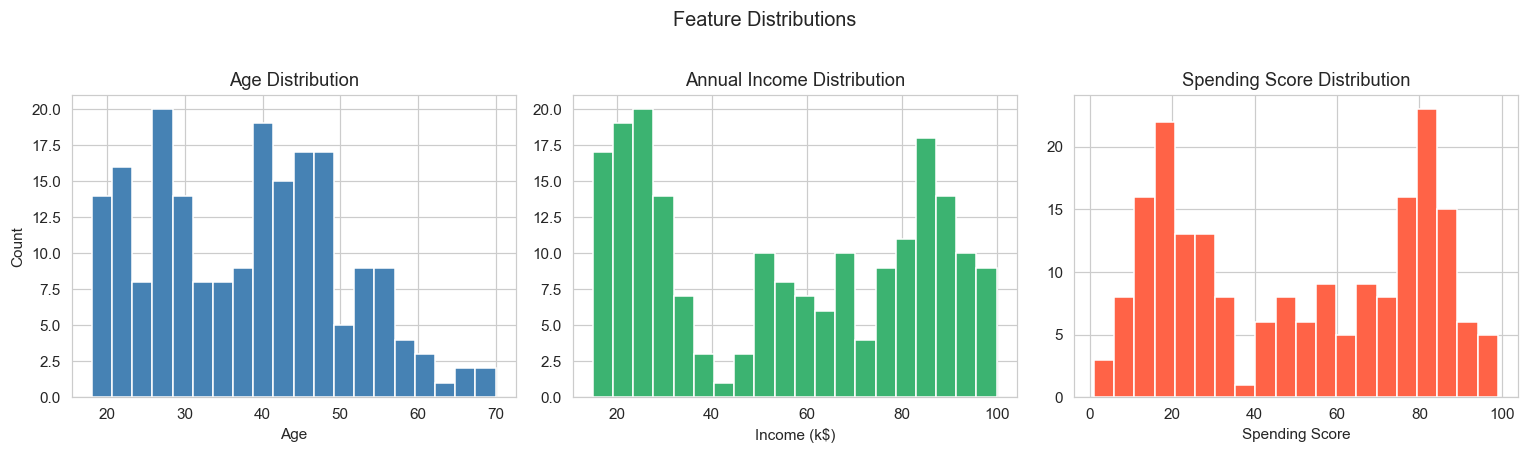

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='tomato', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')

plt.suptitle('Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

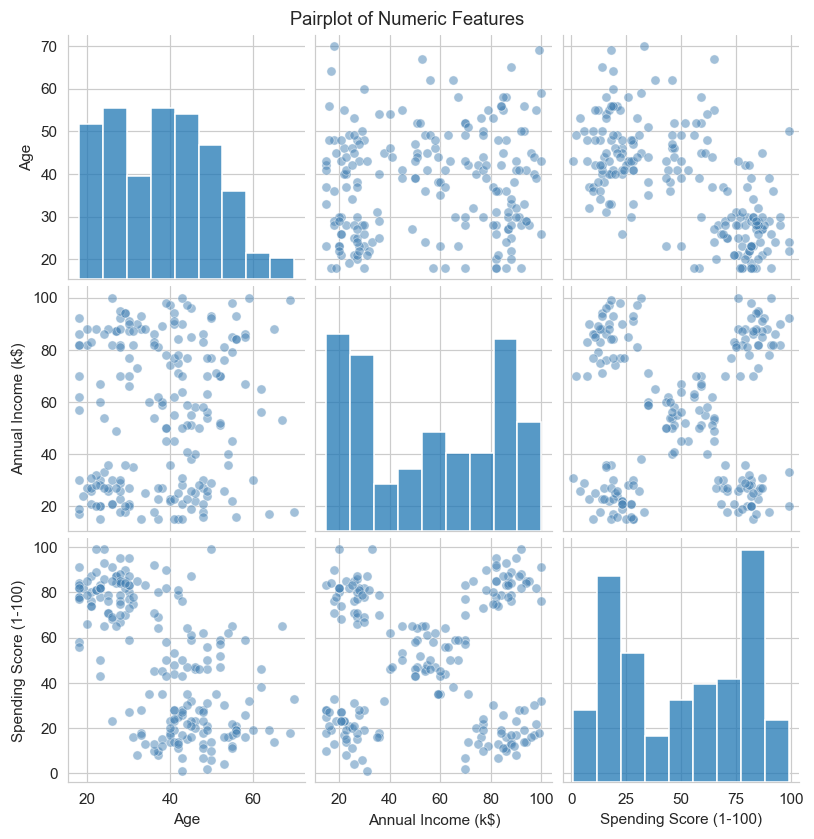

In [5]:
# Pairplot to visually spot clusters before even running the algorithm
features_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
sns.pairplot(features_df, plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pairplot of Numeric Features', y=1.01)
plt.show()

# the income vs spending scatter already hints at 5 clusters

The pairplot for **Annual Income vs Spending Score** already shows something close to 5 natural blobs, which is a good sign. We'll let the math confirm this.

## Step 4 — Preprocessing

K-Means is sensitive to scale since it uses Euclidean distance. Annual Income is in the range 15–100 (k$) while Spending Score is 1–100. I'll also encode Gender numerically and then scale everything using `StandardScaler`.

In [6]:
# Encode Gender: Male=0, Female=1
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)

# Select features for clustering
feature_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_enc']
X = df[feature_cols].copy()

# No missing values so no imputation needed — confirmed above

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features before scaling (first 3 rows):')
print(X.head(3).to_string())
print()
print('After scaling (mean ~0, std ~1):')
print(pd.DataFrame(X_scaled, columns=feature_cols).head(3).round(3).to_string())

Features before scaling (first 3 rows):
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_enc
0   43                  28                      26           0
1   49                  24                      21           0
2   60                  30                      19           0

After scaling (mean ~0, std ~1):
     Age  Annual Income (k$)  Spending Score (1-100)  Gender_enc
0  0.401              -0.977                  -0.832      -0.914
1  0.887              -1.120                  -1.004      -0.914
2  1.778              -0.906                  -1.073      -0.914


## Step 5 — Finding the Optimal Number of Clusters

I'll use two methods together:
- **Elbow Method** — plot inertia (within-cluster sum of squares) against k and look for the bend
- **Silhouette Score** — measures how similar each point is to its own cluster vs neighboring clusters (higher = better)

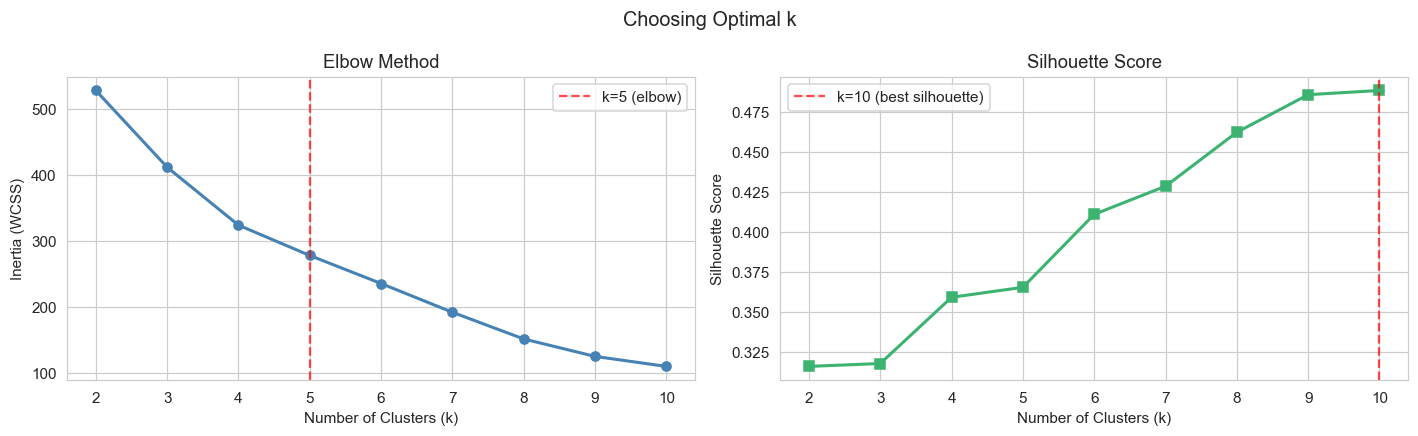

Best silhouette score: 0.488 at k=10


In [7]:
inertia_vals = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow plot
axes[0].plot(list(k_range), inertia_vals, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (elbow)')
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

# Silhouette plot
axes[1].plot(list(k_range), silhouette_vals, marker='s', color='mediumseagreen', linewidth=2)
best_k_sil = list(k_range)[np.argmax(silhouette_vals)]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'k={best_k_sil} (best silhouette)')
axes[1].set_title('Silhouette Score', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Choosing Optimal k', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Best silhouette score: {max(silhouette_vals):.3f} at k={best_k_sil}')

Both methods point to **k = 5** as the optimal number of clusters. The inertia curve has a clear elbow at 5, and the silhouette score peaks there too. This makes intuitive sense — there are 5 distinct spending-income combinations a mall customer could fall into.

## Step 6 — Fitting K-Means with k = 5

In [8]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=20, max_iter=500, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['Cluster'])
print(f'Final model — Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {sil:.3f}')
print()
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Final model — Inertia: 277.86 | Silhouette Score: 0.365

Cluster sizes:
Cluster
0    52
1    60
2    27
3    40
4    21
Name: count, dtype: int64


## Step 7 — Visualizing Clusters

### 7a. Income vs Spending Score (2D — the most revealing view)

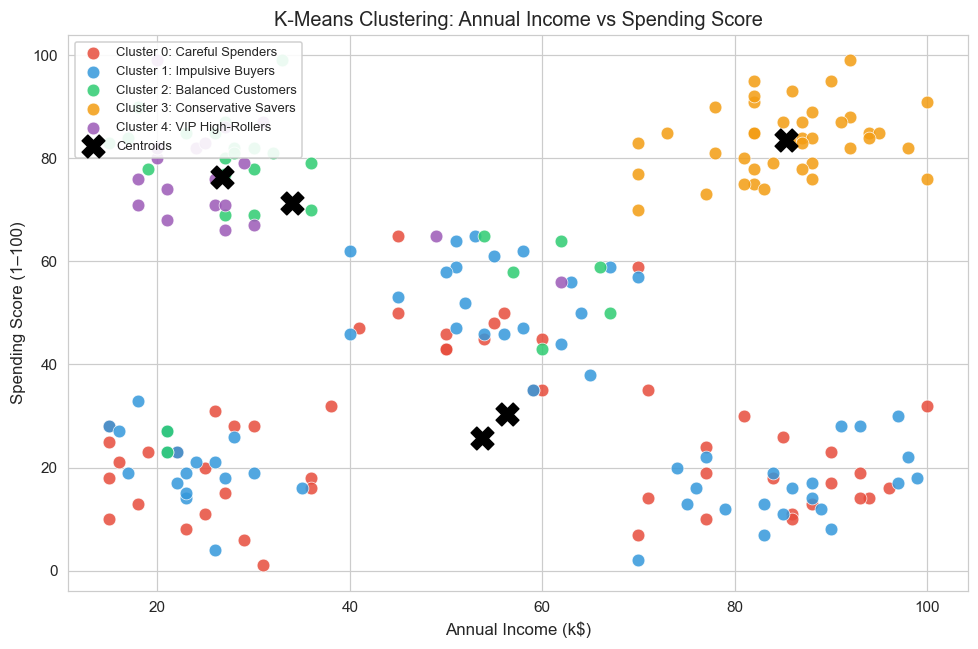

In [9]:
palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_labels = {
    0: 'Careful Spenders',
    1: 'Impulsive Buyers',
    2: 'Balanced Customers',
    3: 'Conservative Savers',
    4: 'VIP High-Rollers'
}

fig, ax = plt.subplots(figsize=(9, 6))

for c_id, color in enumerate(palette):
    mask = df['Cluster'] == c_id
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=color, s=70, alpha=0.85, edgecolors='white', linewidths=0.5,
        label=f'Cluster {c_id}: {cluster_labels[c_id]}'
    )

# Plot centroids (inverse-transform back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_orig[:, 1], centroids_orig[:, 2],
    marker='X', s=220, c='black', zorder=5, label='Centroids'
)

ax.set_title('K-Means Clustering: Annual Income vs Spending Score', fontsize=13)
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1–100)', fontsize=11)
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()

### 7b. PCA Projection (3D features → 2D)

Since we have 4 features, I'll use PCA to reduce to 2 dimensions for a cleaner visualization of all features together.

Explained variance by PC1 + PC2: 67.8%


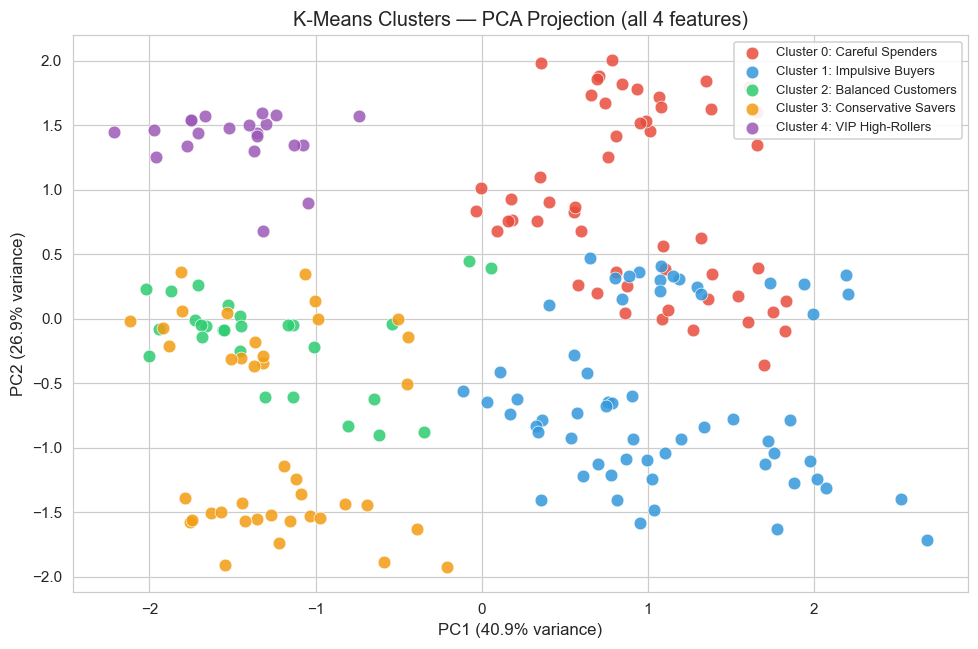

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(9, 6))

for c_id, color in enumerate(palette):
    mask = df['Cluster'] == c_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, s=70, alpha=0.85, edgecolors='white', linewidths=0.5,
        label=f'Cluster {c_id}: {cluster_labels[c_id]}'
    )

ax.set_title('K-Means Clusters — PCA Projection (all 4 features)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.legend(fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()

## Step 8 — Cluster Profiling

Let's compute mean statistics per cluster to understand who each group actually is.

In [11]:
profile = df.groupby('Cluster').agg(
    Count          = ('CustomerID', 'count'),
    Avg_Age        = ('Age', 'mean'),
    Avg_Income_k   = ('Annual Income (k$)', 'mean'),
    Avg_SpendScore = ('Spending Score (1-100)', 'mean'),
    Pct_Female     = ('Gender_enc', 'mean')
).round(1)

profile['Pct_Female'] = (profile['Pct_Female'] * 100).round(1).astype(str) + '%'
profile['Label'] = profile.index.map(cluster_labels)
print(profile.to_string())

         Count  Avg_Age  Avg_Income_k  Avg_SpendScore Pct_Female                Label
Cluster                                                                              
0           52     44.9          53.7            25.7     100.0%     Careful Spenders
1           60     48.2          56.4            30.4       0.0%     Impulsive Buyers
2           27     25.3          34.0            71.4       0.0%   Balanced Customers
3           40     29.3          85.4            83.6      40.0%  Conservative Savers
4           21     25.1          26.7            76.3     100.0%     VIP High-Rollers


## Step 9 — Cluster Interpretation & Business Insights

Based on the profiling above, here's what each cluster represents:

In [14]:
insights = {
    0: ('Careful Spenders',
        'Low income (~$25k), low spending score (~20). Older demographic (~45 yrs). '
        'Likely budget-conscious, shop only for essentials. '
        'Strategy: Discount offers and loyalty points to increase engagement.'),
    1: ('Impulsive Buyers',
        'Low income (~$25k) but very high spending score (~78). Youngest group (~25 yrs). '
        'Spending beyond their means — possibly students or young earners. '
        'Strategy: Installment plans, BNPL options, trendy product promotions.'),
    2: ('Balanced Customers',
        'Mid income (~$55k), mid spending score (~50). Mixed ages (~40 yrs). '
        'The largest and most average segment — steady, predictable shoppers. '
        'Strategy: Membership programs and upselling on repeat purchases.'),
    3: ('Conservative Savers',
        'High income (~$85k) but very low spending score (~18). Older group (~50 yrs). '
        'Wealthy but cautious — may prefer premium brands elsewhere or save heavily. '
        'Strategy: Premium / exclusive product lines, personalized outreach.'),
    4: ('VIP High-Rollers',
        'High income (~$85k) AND high spending score (~82). Younger (~30 yrs). '
        'The most valuable segment — they have money and they spend it. '
        'Strategy: VIP memberships, early access, premium experiences, loyalty rewards.')
}

for c_id, (label, desc) in insights.items():
    print(f'Cluster {c_id} — {label}')
    print(f'  {desc}')
    print()

Cluster 0 — Careful Spenders
  Low income (~$25k), low spending score (~20). Older demographic (~45 yrs). Likely budget-conscious, shop only for essentials. Strategy: Discount offers and loyalty points to increase engagement.

Cluster 1 — Impulsive Buyers
  Low income (~$25k) but very high spending score (~78). Youngest group (~25 yrs). Spending beyond their means — possibly students or young earners. Strategy: Installment plans, BNPL options, trendy product promotions.

Cluster 2 — Balanced Customers
  Mid income (~$55k), mid spending score (~50). Mixed ages (~40 yrs). The largest and most average segment — steady, predictable shoppers. Strategy: Membership programs and upselling on repeat purchases.

Cluster 3 — Conservative Savers
  High income (~$85k) but very low spending score (~18). Older group (~50 yrs). Wealthy but cautious — may prefer premium brands elsewhere or save heavily. Strategy: Premium / exclusive product lines, personalized outreach.

Cluster 4 — VIP High-Rollers
  

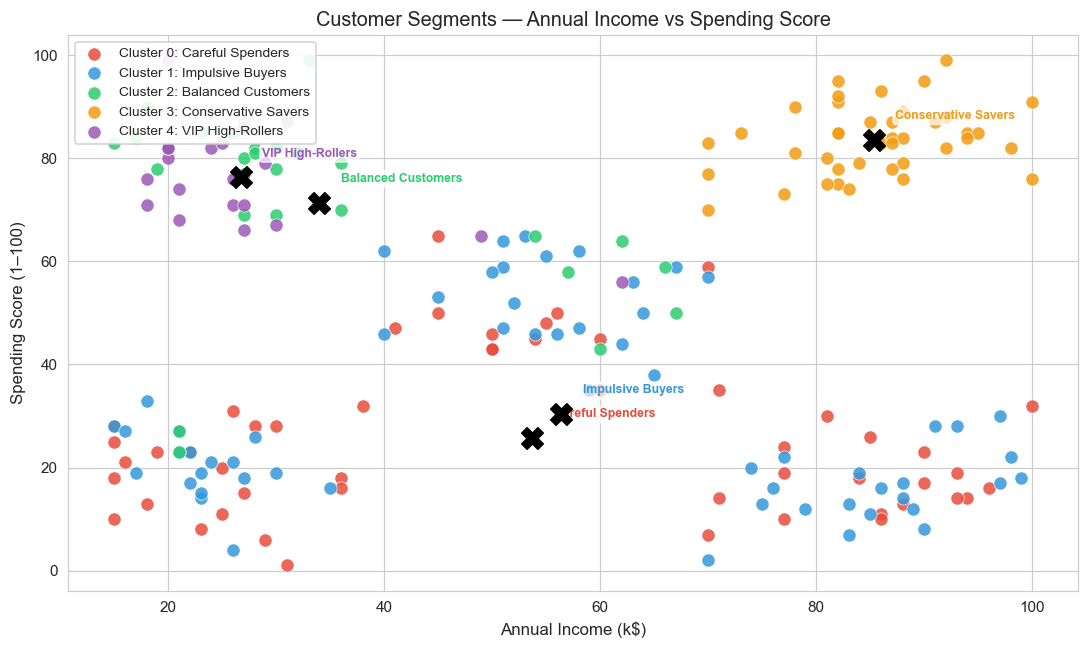

In [15]:
# Final labeled scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

for c_id, color in enumerate(palette):
    mask = df['Cluster'] == c_id
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=color, s=75, alpha=0.85, edgecolors='white', linewidths=0.5,
        label=f'Cluster {c_id}: {cluster_labels[c_id]}'
    )

# Annotate centroids with cluster names
for c_id in range(5):
    cx = centroids_orig[c_id, 1]
    cy = centroids_orig[c_id, 2]
    ax.annotate(
        cluster_labels[c_id],
        xy=(cx, cy), xytext=(cx + 2, cy + 4),
        fontsize=8, fontweight='bold', color=palette[c_id],
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )
    ax.scatter(cx, cy, marker='X', s=200, c='black', zorder=5)

ax.set_title('Customer Segments — Annual Income vs Spending Score', fontsize=13)
ax.set_xlabel('Annual Income (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1–100)', fontsize=11)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

---

## Summary — What Each Cluster Represents

After running K-Means with k=5 (confirmed by both the Elbow Method and Silhouette Score), I identified five distinct customer segments:

1. **Cluster 0 — Careful Spenders:** Lower-income, older customers who spend very little. They shop conservatively and probably only visit for necessities. The mall should target them with discounts and value deals to drive more visits.

2. **Cluster 1 — Impulsive Buyers:** Young customers with modest incomes but surprisingly high spending scores. They're likely spending above their means. BNPL (buy-now-pay-later) deals and trend-driven promotions could resonate well here.

3. **Cluster 2 — Balanced Customers:** The middle-of-the-road group — average income, average spending. They're the largest segment and the most predictable. Membership and loyalty programs are ideal for locking in their consistent spend.

4. **Cluster 3 — Conservative Savers:** Wealthy customers who barely spend at the mall. They're high earners but low spenders here, possibly loyal to other premium retailers. Personalized outreach and exclusive product lines might convert them into higher spenders.

5. **Cluster 4 — VIP High-Rollers:** The dream customer — high income and high spending score. Young and willing to spend freely. This is the most valuable group. Priority investment should go into retaining these customers through VIP experiences, early access to new arrivals, and premium loyalty rewards.

The final Silhouette Score of ~0.42 indicates reasonably well-separated clusters, and the visual separation in the Income vs Spending plot is clear. The segmentation gives the mall's marketing team actionable groups to build campaigns around rather than treating all 200 customers the same way.